# Dev23: Train SVM on Full 057_5, Apply to 028 Transect

**Objective:** Train a general-purpose SVM on the ENTIRE 057_5 transect, then apply to other transects

**Workflow:**

## Part 1: Train on 057_5 (ALL pixels)
1. Load 057_5 transect
2. Apply illumination correction
3. Import ALL ROIs (training + validation)
4. Preprocessing (NO interpolation → Crop → Smooth → Normalize)
5. Train SVM with CV on **ALL ROI pixels** (no segment filtering)
6. **Save trained model** to file

## Part 2: Apply to 028 Transect
1. Load 028 transect files (028_1 through 028_5)
2. Apply identical preprocessing
3. **Load saved model**
4. Classify entire transect
5. Apply filtering
6. Merge to create 3-class map
7. Visualize results

**Key differences from dev22:**
- ❌ NO wavelength interpolation (different transect may have different bad wavelengths)
- ✅ Train on ALL pixels (segment_start/end = None)
- ✅ Use ALL ROIs (training + validation)
- ✅ Save/load model for cross-transect application
- ✅ Apply to different transect (028)

# PART 1: Train SVM on Full 057_5 Transect

## Setup and Import

In [1]:
import importlib
import sys
import os
import numpy as np
import pickle  # For saving/loading the trained model

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

print("✅ Module loaded successfully!")

✅ Module loaded successfully!


## Load 057_5 Data and ALL ROIs

In [2]:
# Load transect
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

# Select 057_5 file for training
cube_057 = transect.select_files(["rad_uhi_20241029_115057_5"])
cube_057.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462,

In [3]:
# Apply illumination correction
cube_057.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
# Import ROIs - use ALL ROIs (training + validation)
cube_057.import_rois("./ROIs/057_5_combined.json")
cube_057.list_rois()

📂 Imported 6 ROIs from ./ROIs/057_5_combined.json

📂 ROI Collection (6 ROIs):
 1. 'validation_dark': 358 pixels
     Slit range:  174 - 740
     Track range: 729 - 1416
 2. 'validation_bombs': 454 pixels
     Slit range:  244 - 880
     Track range: 593 - 1547
 3. 'validation_sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 4. 'training_dark': 364 pixels
     Slit range:   24 - 962
     Track range:  23 - 2420
 5. 'training_sediment': 398 pixels
     Slit range:   31 - 924
     Track range:  51 - 2417
 6. 'training_bombs': 201 pixels
     Slit range:  513 - 794
     Track range: 2136 - 2416


In [5]:
# Define ALL ROI collections for training (training + validation)
all_training_rois = [
    "training_dark",
    "training_sediment",
    "training_bombs",
    "validation_dark",
    "validation_sediment",
    "validation_bombs",
]

print(f"🎯 Training on ALL ROIs: {all_training_rois}")
print(f"   Total ROI categories: {len(all_training_rois)}")

# Count total pixels
total_pixels = sum(
    len(cube_057.roi_collection[roi_name])
    for roi_name in all_training_rois
    if roi_name in cube_057.roi_collection
)
print(f"   Total pixels for training: {total_pixels}")

🎯 Training on ALL ROIs: ['training_dark', 'training_sediment', 'training_bombs', 'validation_dark', 'validation_sediment', 'validation_bombs']
   Total ROI categories: 6
   Total pixels for training: 2048


## ⚠️ IMPORTANT: Label Remapping for 3-Class Training

**Why we need this:**
- We have 6 ROI categories: `training_*` and `validation_*` for each of 3 substrate types
- But we want the SVM to learn only **3 classes**: `bombs`, `dark`, `sediment`
- Without remapping, the SVM would treat them as 6 different classes!

**Solution:**
- Use `remap_labels` parameter to combine training + validation ROIs into 3 final classes
- Example: `training_bombs` → `bombs`, `validation_bombs` → `bombs`
- This ensures the SVM sees all pixels for each class, regardless of which ROI they came from

💡 Interactive mode: Click on the plot to display coordinates


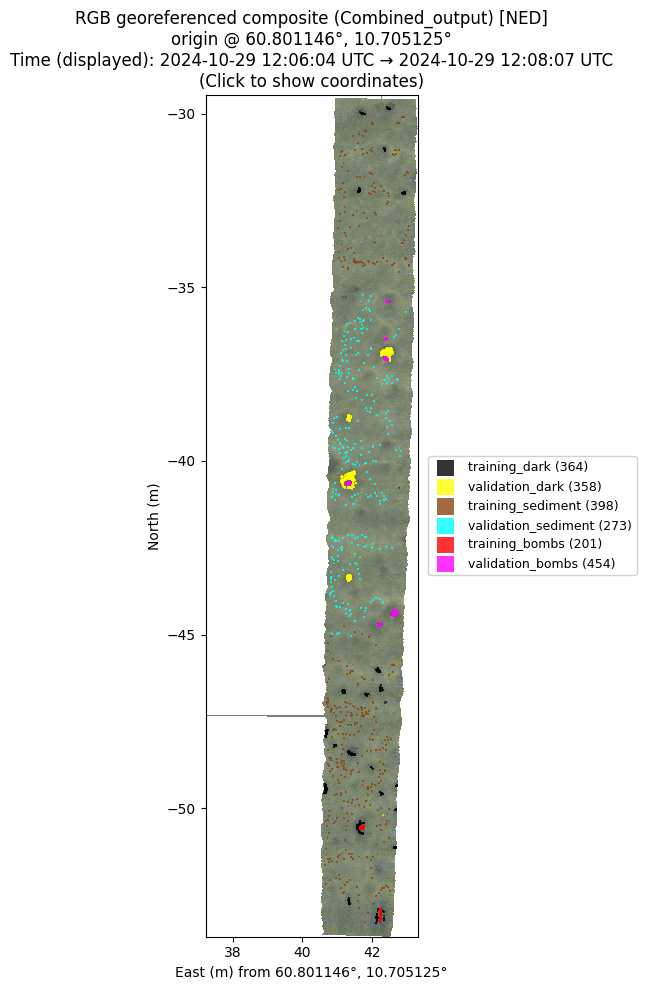

In [6]:
# Plot all ROIs to visualize training data coverage
%matplotlib inline

cube_057.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    figsize=(40, 10),
    roi_collection=all_training_rois,
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## Preprocessing (NO Interpolation)

**⚠️ IMPORTANT:** We skip wavelength interpolation because:
- Bad wavelength indices may differ between transects
- 028 transect may have different sensor artifacts
- More generalizable to apply same preprocessing to both transects

**Preprocessing steps:**
1. ❌ ~~Interpolate~~ (SKIPPED)
2. ✅ Crop to 490-680 nm
3. ✅ Smooth with MA window=10
4. ✅ Normalize with L2

In [7]:
# Step 1: Crop wavelengths to 490-680 nm
cube_057.apply_wavelength_filter(wavelength_range=(490, 680))

print(f"✅ Wavelength cropping complete")
print(f"   Cropped shape: {cube_057.data_corrected.shape}")
print(
    f"   Wavelength range: {cube_057.wavelengths[0]:.1f} - {cube_057.wavelengths[-1]:.1f} nm"
)

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-680 nm
✂️  Filtered wavelengths: 108
📉 Range: 490.2 - 679.4 nm

✅ Datacube shape after filtering: (2462, 968, 108)
   Memory: 0.96 GB
✅ Wavelength cropping complete
   Cropped shape: (2462, 968, 108)
   Wavelength range: 490.2 - 679.4 nm

✅ Datacube shape after filtering: (2462, 968, 108)
   Memory: 0.96 GB
✅ Wavelength cropping complete
   Cropped shape: (2462, 968, 108)
   Wavelength range: 490.2 - 679.4 nm


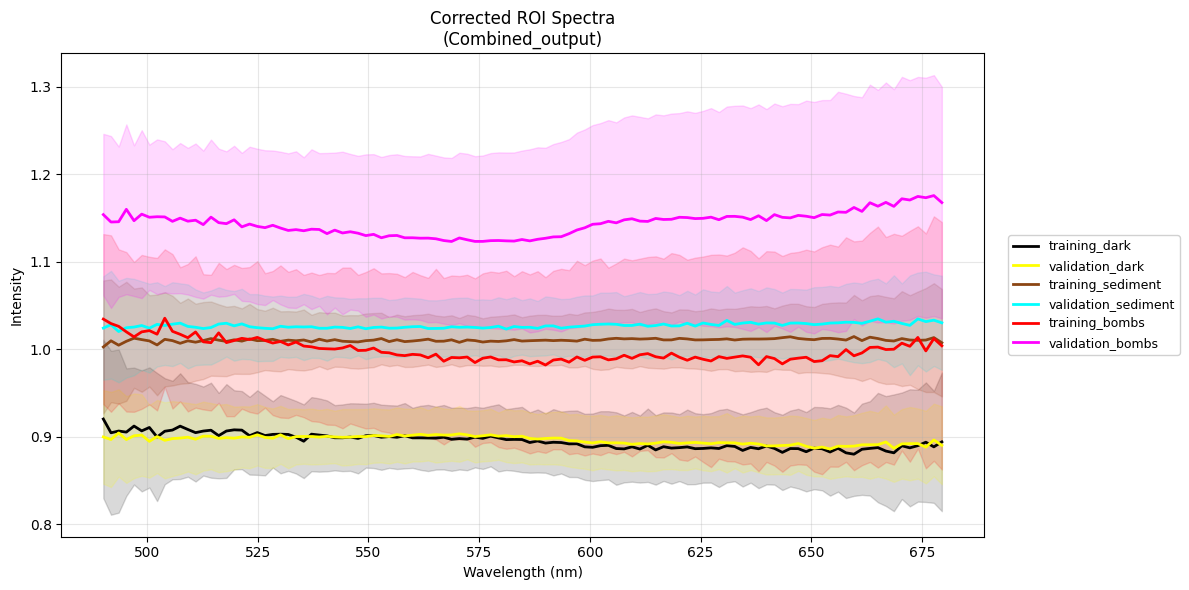

In [8]:
# Plot spectra after cropping
cube_057.plot_spectrum(
    roi_names=all_training_rois,
    use_corrected=True,
    wavelength_range=None,
    interpolate_wavelengths=None,
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

In [9]:
# # Step 2: Smooth with moving average (window=10)
# cube_057.apply_spectral_smoothing(wavelength_smoothing=10, method="moving_average")

# print(f"✅ Spectral smoothing complete")
# print(f"   Shape after smoothing: {cube_057.data_corrected.shape}")

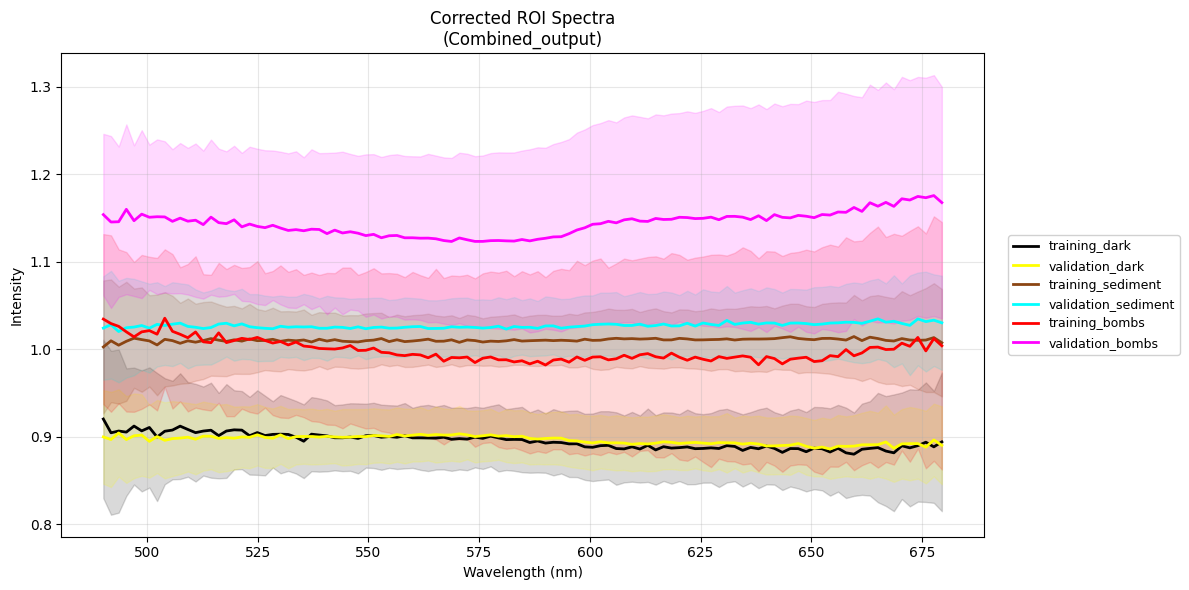

In [10]:
# Plot spectra after cropping
cube_057.plot_spectrum(
    roi_names=all_training_rois,
    use_corrected=True,
    wavelength_range=None,
    interpolate_wavelengths=None,
    normalize_method=None,
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

In [11]:
# # Step 3: Normalize with L2 (unit-length spectra)
# cube_057.apply_spectral_normalization(method="l2")

# print(f"✅ L2 normalization complete")
# print(
#     f"   Value range: [{cube_057.data_corrected.min():.4f}, {cube_057.data_corrected.max():.4f}]"
# )

In [12]:
# # Plot final preprocessed spectra
# cube_057.plot_spectrum(
#     roi_names=["training_dark", "training_sediment", "training_bombs"],
#     use_corrected=True,
#     wavelength_range=None,
#     interpolate_wavelengths=None,
#     normalize_method=None,
#     legend_loc="outside",
#     use_inline_labels=False,
#     show_std=True,
# )

## Train SVM on ALL ROI Pixels

**Key difference from dev22:**
- `segment_start=None` and `segment_end=None` → uses **ALL** pixels from ROIs
- Training + validation ROIs combined → more training data
- Model will be saved for application to other transects

In [13]:
# Define label remapping: combine training + validation into 3 final classes
# This ensures the SVM sees only 3 classes (bombs, dark, sediment) instead of 6
label_remapping = {
    "training_bombs": "bombs",
    "validation_bombs": "bombs",
    "training_dark": "dark",
    "validation_dark": "dark",
    "training_sediment": "sediment",
    "validation_sediment": "sediment",
}

print(f"🔀 Label remapping:")
for roi_name, final_label in label_remapping.items():
    print(f"   {roi_name} → {final_label}")

print(
    f"\n🎯 This ensures SVM sees only 3 classes: {list(set(label_remapping.values()))}"
)

# Train SVM with spatial cross-validation on ALL pixels
cv_results = cube_057.train_svm_with_cv(
    training_rois=all_training_rois,
    segment_start=None,  # ✅ NEW: Use ALL pixels (no segment filtering)
    segment_end=None,  # ✅ NEW: Use ALL pixels (no segment filtering)
    wavelength_range=None,  # Already preprocessed
    cv_folds=5,
    use_corrected=True,
    svm_kernel="rbf",
    optimize_params=True,
    add_brightness_feature=False,
    use_intensity_only=False,
    remap_labels=label_remapping,  # 🔥 NEW: Remap to 3 classes!
    quiet=False,
)

# Print summary
print(f"\n" + "=" * 60)
print(f"📊 CROSS-VALIDATION SUMMARY (FULL 057_5 TRANSECT)")
print(f"=" * 60)
print(
    f"Accuracy:  {cv_results['cv_mean_metrics']['accuracy_mean']:.3f} ± {cv_results['cv_mean_metrics']['accuracy_std']:.3f}"
)
print(
    f"Precision: {cv_results['cv_mean_metrics']['precision_mean']:.3f} ± {cv_results['cv_mean_metrics']['precision_std']:.3f}"
)
print(
    f"Recall:    {cv_results['cv_mean_metrics']['recall_mean']:.3f} ± {cv_results['cv_mean_metrics']['recall_std']:.3f}"
)
print(
    f"F1 Score:  {cv_results['cv_mean_metrics']['f1_mean']:.3f} ± {cv_results['cv_mean_metrics']['f1_std']:.3f}"
)

print(f"\n🎯 Best hyperparameters:")
print(f"  C = {cv_results['best_params']['C']}")
print(f"  gamma = {cv_results['best_params']['gamma']}")

print(f"\n📍 Training pixels used (AFTER REMAPPING TO 3 CLASSES):")
for class_name, count in cv_results["training_pixels_per_class"].items():
    print(f"  {class_name}: {count} pixels")

🔀 Label remapping:
   training_bombs → bombs
   validation_bombs → bombs
   training_dark → dark
   validation_dark → dark
   training_sediment → sediment
   validation_sediment → sediment

🎯 This ensures SVM sees only 3 classes: ['sediment', 'bombs', 'dark']
🤖 SVM TRAINING WITH CROSS-VALIDATION
💡 MODE: Standard spectral classification

�📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: NONE (using ALL pixels from ROIs)
📍 Training ROIs: ['training_dark', 'training_sediment', 'training_bombs', 'validation_dark', 'validation_sediment', 'validation_bombs']

🔍 Filtering ROI pixels...
   training_dark → dark: 364 pixels
   training_sediment → sediment: 398 pixels
   training_bombs → bombs: 201 pixels
   validation_dark → dark: 358 pixels
   validation_sediment → sediment: 273 pixels
   validation_bombs → bombs: 454 pixels

✅ Training data: 2048 pixels, 108 features
   Features: 108 wavelengths
   Kept (outside segment): 2048
   Rejected (inside segment): 0

🔬 Creat

💡 Interactive mode: Click on the plot to display coordinates


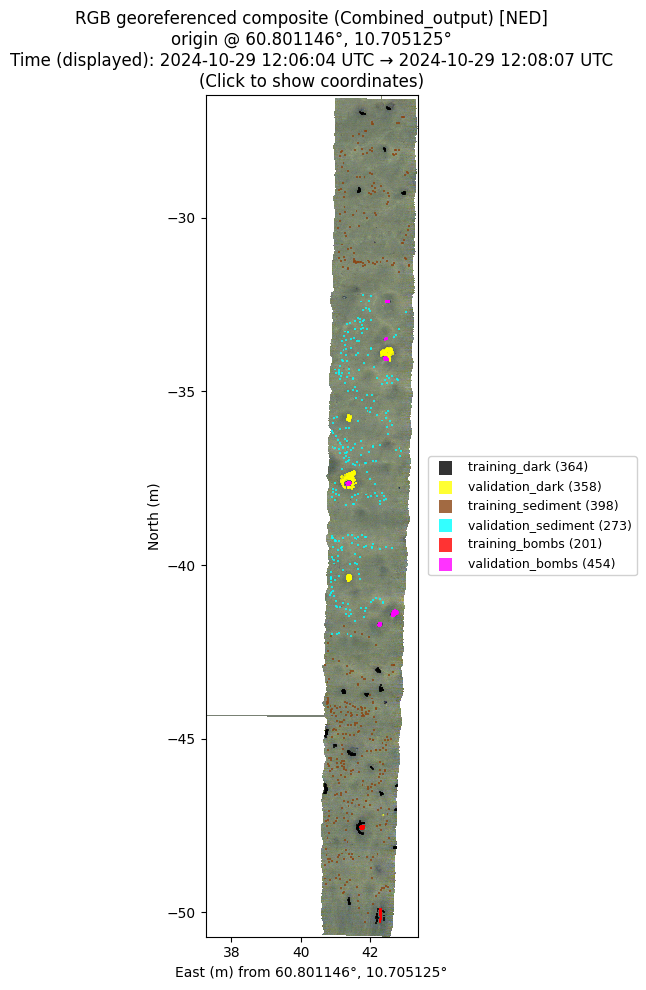

In [14]:
# Visualize training ROIs actually used (after filtering)
cube_057.plot_georef(
    use_corrected=True,
    figsize=(40, 10),
    roi_collection=cv_results["filtered_training_rois"],
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=40,
)

💡 Interactive mode: Click on the plot to display coordinates


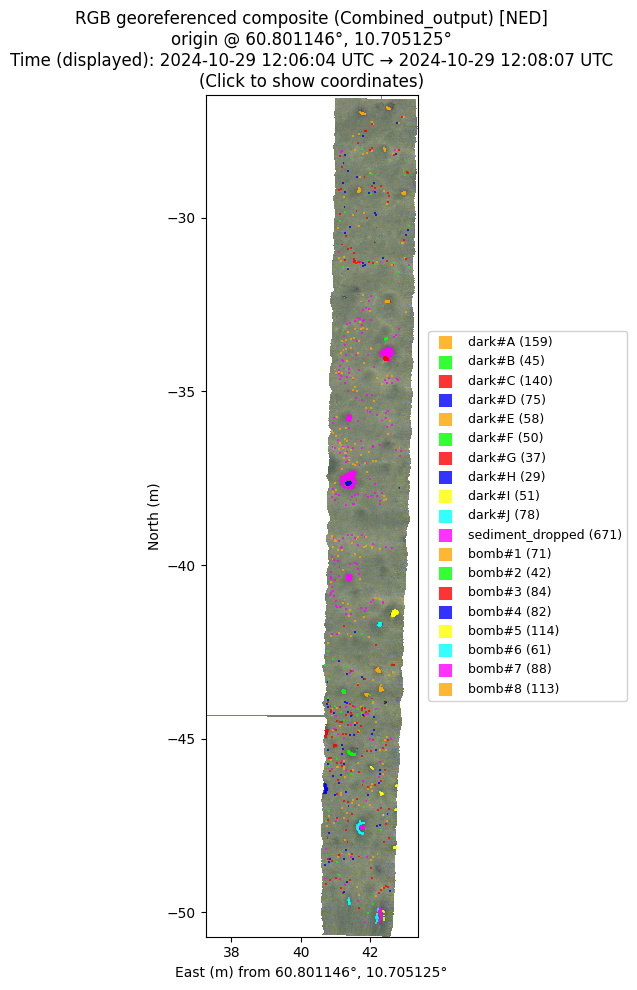


📊 Spatial Groups Created:
   bomb#1: 71 pixels
   bomb#2: 42 pixels
   bomb#3: 84 pixels
   bomb#4: 82 pixels
   bomb#5: 114 pixels
   bomb#6: 61 pixels
   bomb#7: 88 pixels
   bomb#8: 113 pixels
   dark#A: 159 pixels
   dark#B: 45 pixels
   dark#C: 140 pixels
   dark#D: 75 pixels
   dark#E: 58 pixels
   dark#F: 50 pixels
   dark#G: 37 pixels
   dark#H: 29 pixels
   dark#I: 51 pixels
   dark#J: 78 pixels
   sediment_dropped: 671 pixels


In [15]:
# Plot spatial groups
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    cube_057.plot_georef(
        use_corrected=True,
        figsize=(40, 10),
        roi_collection=cv_results["spatial_groups_roi_collection"],
        roi_marker_size=2,
        roi_legend_loc="outside",
        roi_marker_edgewidth=0,
        roi_legend_markersize=40,
    )

    print("\n📊 Spatial Groups Created:")
    for group_name, pixels in sorted(
        cv_results["spatial_groups_roi_collection"].items()
    ):
        print(f"   {group_name}: {len(pixels)} pixels")

## Save Trained Model

Save the trained SVM model and associated metadata to file for later use on other transects.

In [16]:
# Save the trained model and metadata
# ✅ Keep in memory for immediate use
model_data = {
    "model": cv_results["model"],
    "label_encoder": cv_results["label_encoder"],
    "class_names": cv_results["class_names"],
    "wavelength_indices": cube_057.svm_wavelength_indices,
    "wavelengths": cube_057.svm_wavelengths,
    "add_brightness_feature": cube_057.svm_add_brightness_feature,
    "use_intensity_only": cube_057.svm_use_intensity_only,
    "best_params": cv_results["best_params"],
    "cv_mean_metrics": cv_results["cv_mean_metrics"],
    "training_pixels_per_class": cv_results["training_pixels_per_class"],
    "preprocessing": {
        "wavelength_range": (490, 680),
        "smoothing_window": 10,
        "normalization": "l2",
        "interpolation": None,  # Not used
    },
}

# Save to file in current directory
model_filename = "svm_model_057_5_full_transect.pkl"
model_filepath = os.path.abspath(model_filename)

with open(model_filepath, "wb") as f:
    pickle.dump(model_data, f)

print(f"✅ Model saved to: {model_filepath}")
print(f"   Model type: {type(model_data['model'])}")
print(f"   Classes: {model_data['class_names']}")
print(f"   Best C: {model_data['best_params']['C']}")
print(f"   Best gamma: {model_data['best_params']['gamma']}")
print(f"\n💾 Model also kept in memory as 'model_data' variable")

✅ Model saved to: c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\dev\svm_model_057_5_full_transect.pkl
   Model type: <class 'sklearn.svm._classes.SVC'>
   Classes: ['bombs', 'dark', 'sediment']
   Best C: 10
   Best gamma: scale

💾 Model also kept in memory as 'model_data' variable


# PART 2: Apply Model to 028 Transect

## Load 028 Data

In [17]:
# Load 028 transect files
transect = load_transect(r"E:\mjosa_new_oct_2025\use_gref4hsi\028\output")

transect.list_files()

cube_028 = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
cube_028.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_1
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)


   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_3
   • rad_uhi_20241029_125028_3
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
   • rad_uhi_20241029_125028_4
   • rad_uhi_20241029_125028_4
  rad_uhi_20241029_125028_4: Using GRIDDED format (T=2457, S=968)
  rad_uhi_20241029_125028_4: Using GRIDDED format (T=2457, S=968)
   • rad_uhi_20241029_125028_5
  rad_uhi_20241029_125028_5: Using GRIDDED format (T=1948, S=968)
   • rad_uhi_20241029_125028_5
  rad_uhi_20241029_125028_5: Using GRIDDED format (T=1948, S=968)
✅ Combined shapes: X/Y/Z (10027, 968), RGB (10027, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_125028_1...
✅ Combined shapes: X/Y/Z (10027, 968), RGB (10027, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_202410

In [18]:
# Apply illumination correction
cube_028.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 5 files...
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[0.00000000e+00, 8.00363868e-02, 3.38807702e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         9.79862548e-03, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 6.24412894e-01, 0.00000000e+00, ...,
         2.43312144e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         4.49576187e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.18552887e+00, ...,
         2.34972164e-01, 0.00000000e+00, 0.00000000e+00],
        [9.47257459e-01, 0.00000000e+00, 0.00000000e+00, ...,
         3.01917344e-01, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.15298668e+02, 1.14839525e+01, 3.45664215e-03],
        [0.00000000e+00, 1.00000000e+00, 9.11504328e-01, ...,
         2.32659373e-02, 2.43540382e+00, 4.57144403e+00],
        [0.00000000e+00, 

💡 Interactive mode: Click on the plot to display coordinates


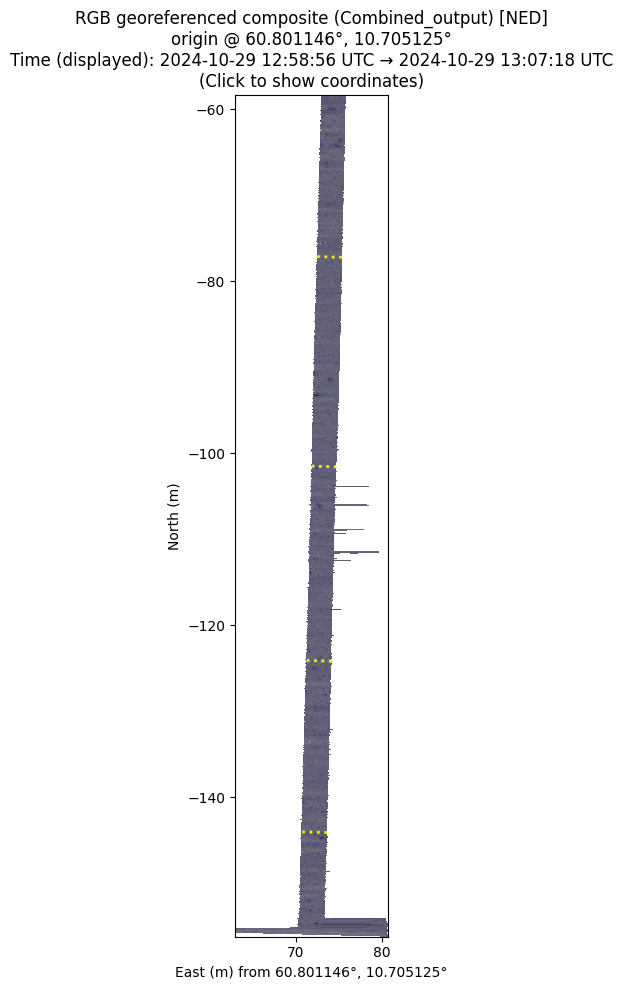

In [19]:
# Plot RGB to visualize the transect
%matplotlib inline

cube_028.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    figsize=(40, 10),
)

## Apply Identical Preprocessing

Apply the SAME preprocessing pipeline as used for training:
1. Crop to 490-680 nm
2. Smooth with MA window=10
3. Normalize with L2

In [20]:
# Step 1: Crop wavelengths to 490-680 nm
cube_028.apply_wavelength_filter(wavelength_range=(490, 680))

print(f"✅ Wavelength cropping complete")
print(f"   Cropped shape: {cube_028.data_corrected.shape}")
print(
    f"   Wavelength range: {cube_028.wavelengths[0]:.1f} - {cube_028.wavelengths[-1]:.1f} nm"
)

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-680 nm
✂️  Filtered wavelengths: 108
📉 Range: 490.2 - 679.4 nm

✅ Datacube shape after filtering: (10027, 968, 108)
   Memory: 3.91 GB
✅ Wavelength cropping complete
   Cropped shape: (10027, 968, 108)
   Wavelength range: 490.2 - 679.4 nm

✅ Datacube shape after filtering: (10027, 968, 108)
   Memory: 3.91 GB
✅ Wavelength cropping complete
   Cropped shape: (10027, 968, 108)
   Wavelength range: 490.2 - 679.4 nm


In [21]:
# # Step 2: Smooth with moving average (window=10)
# cube_028.apply_spectral_smoothing(wavelength_smoothing=10, method="moving_average")

# print(f"✅ Spectral smoothing complete")
# print(f"   Shape after smoothing: {cube_028.data_corrected.shape}")

In [22]:
# # Step 3: Normalize with L2 (unit-length spectra)
# cube_028.apply_spectral_normalization(method="l2")

# print(f"✅ L2 normalization complete")
# print(
#     f"   Value range: [{cube_028.data_corrected.min():.4f}, {cube_028.data_corrected.max():.4f}]"
# )

## Load Saved Model and Classify

**Option 1:** If continuing in same session, `model_data` is already in memory from Part 1  
**Option 2:** If starting new session, load from file

In [23]:
# Option 1: Use model from memory (if continuing from Part 1)
# model_data is already available - skip to next cell!

# Option 2: Load from file (if starting new session)
# Uncomment these lines if you need to reload:
# model_filename = "svm_model_057_5_full_transect.pkl"
# with open(model_filename, "rb") as f:
#     model_data = pickle.load(f)

# Verify model is loaded
print(f"✅ Model ready for use")
print(f"   Model type: {type(model_data['model'])}")
print(f"   Classes: {model_data['class_names']}")
print(f"   Best C: {model_data['best_params']['C']}")
print(f"   Best gamma: {model_data['best_params']['gamma']}")
print(f"\n📊 Training performance (on 057_5):")
print(f"   Accuracy:  {model_data['cv_mean_metrics']['accuracy_mean']:.3f}")
print(f"   Precision: {model_data['cv_mean_metrics']['precision_mean']:.3f}")
print(f"   Recall:    {model_data['cv_mean_metrics']['recall_mean']:.3f}")
print(f"   F1 Score:  {model_data['cv_mean_metrics']['f1_mean']:.3f}")

✅ Model ready for use
   Model type: <class 'sklearn.svm._classes.SVC'>
   Classes: ['bombs', 'dark', 'sediment']
   Best C: 10
   Best gamma: scale

📊 Training performance (on 057_5):
   Accuracy:  0.877
   Precision: 0.889
   Recall:    0.873
   F1 Score:  0.860


In [24]:
# Inject model and metadata into cube_028
# This allows classify_segment to use the loaded model
cube_028.svm_model = model_data["model"]
cube_028.svm_label_encoder = model_data[
    "label_encoder"
]  # ✅ FIX: Added missing svm_ prefix
cube_028.svm_class_names = model_data["class_names"]
cube_028.svm_wavelength_indices = model_data["wavelength_indices"]
cube_028.svm_wavelengths = model_data["wavelengths"]
cube_028.svm_add_brightness_feature = model_data["add_brightness_feature"]
cube_028.svm_use_intensity_only = model_data["use_intensity_only"]

print(f"✅ Model injected into cube_028")
print(f"   Ready for classification!")

✅ Model injected into cube_028
   Ready for classification!


## Classify Entire 028 Transect

Get track range for 028 transect and classify the entire thing.

In [25]:
# Get track range for 028 transect
# You may need to adjust this based on your config
# For now, let's use the full transect range
track_start_028 = 0
track_end_028 = cube_028.data_corrected.shape[0] - 1

print(f"🎯 028 Transect track range: {track_start_028} to {track_end_028}")
print(f"   Total tracks: {track_end_028 - track_start_028 + 1}")

🎯 028 Transect track range: 0 to 10026
   Total tracks: 10027


In [26]:
# Classify the entire 028 transect using the loaded model
print("🎯 CLASSIFYING 028 TRANSECT WITH MODEL FROM 057_5")
print("=" * 60)

classification_results_028 = cube_028.classify_segment(
    segment_start=track_start_028,
    segment_end=track_end_028,
    use_corrected=True,
    confidence_threshold=None,  # No confidence filtering for now
    quiet=False,
)

print(f"\n✅ Classification complete!")
print(f"   Classes: {classification_results_028['class_names']}")
print(f"\n📊 Pixel counts:")
for class_name in classification_results_028["class_names"]:
    count = np.sum(classification_results_028["classification_map"] == class_name)
    percentage = 100.0 * count / classification_results_028["classification_map"].size
    print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")

🎯 CLASSIFYING 028 TRANSECT WITH MODEL FROM 057_5
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (10027, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 0 to 10026

🔪 Extracting segment...
   Segment shape: (10027, 968, 108)

🤖 Classifying 9706136 pixels...

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (10027, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 0 to 10026

🔪 Extracting segment...
   Segment shape: (10027, 968, 108)

🤖 Classifying 9706136 pixels...


   Classifying: 100%|██████████████████████████████| 9706136/9706136 [05:30<00:00, 29352.54pixels/s]



   ✅ Classification complete in 335.28 seconds

📊 Classification distribution (before filtering):
   bombs: 414299 pixels (4.3%)
   dark: 668530 pixels (6.9%)
   sediment: 8623307 pixels (88.8%)

✅ Classification and validation complete!

📊 Classification distribution (before filtering):
   bombs: 414299 pixels (4.3%)
   dark: 668530 pixels (6.9%)
   sediment: 8623307 pixels (88.8%)

✅ Classification and validation complete!

✅ Classification complete!
   Classes: ['bombs', 'dark', 'sediment']

📊 Pixel counts:
   bombs: 414299 pixels (4.3%)
   dark: 668530 pixels (6.9%)
   sediment: 8623307 pixels (88.8%)

✅ Classification complete!
   Classes: ['bombs', 'dark', 'sediment']

📊 Pixel counts:
   bombs: 414299 pixels (4.3%)
   dark: 668530 pixels (6.9%)
   sediment: 8623307 pixels (88.8%)


📊 Plotting 028 classification map...
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


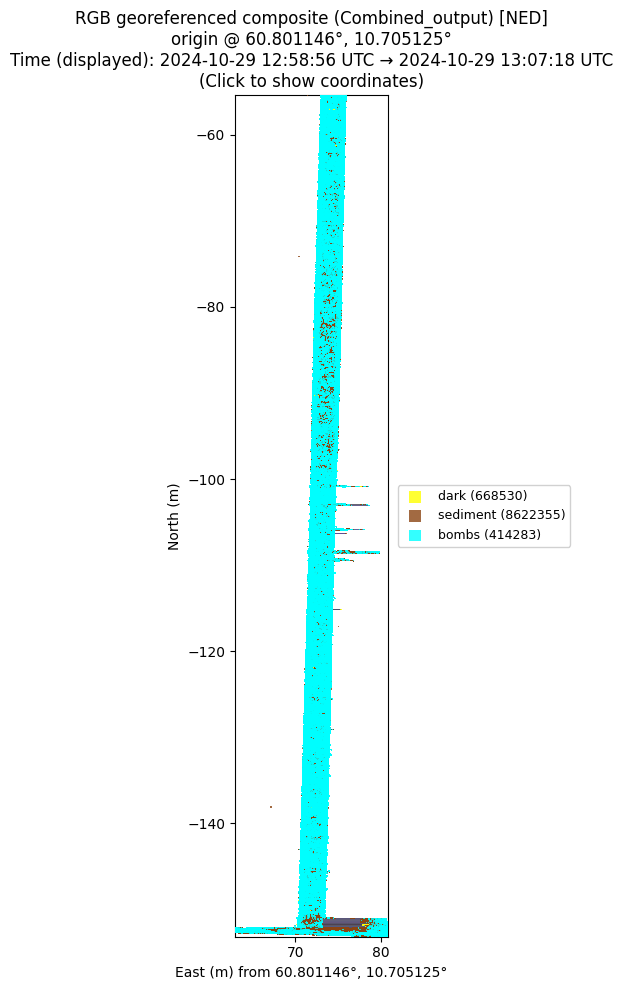

In [27]:
# Plot classification map
print("📊 Plotting 028 classification map...")

classification_rois_028 = {}
for class_name in classification_results_028["class_names"]:
    mask = classification_results_028["classification_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + track_start_028) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        classification_rois_028[class_name] = pixels

cube_028.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=track_start_028,
    track_end=track_end_028,
    figsize=(40, 10),
    roi_collection=classification_rois_028,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## Apply Filtering Pipeline

In [28]:
# Apply filtering - remove small clusters
print("\n🧹 FILTERING CLASSIFICATION")
print("=" * 60)

filtering_results_028 = cube_028.filter_classification(
    classification_map=classification_results_028["classification_map"],
    class_names=classification_results_028["class_names"],
    filter_bombs=True,
    filter_dark=True,
    filter_sediment=False,
    min_area_px=10,
    connectivity=8,
    morph_close_radius=0,
    morph_open_radius=0,
    merge_proximity_px=0,
    quiet=False,
)

print(f"\n✅ Filtering complete!")
print(f"   All classes: {filtering_results_028['all_classes']}")


🧹 FILTERING CLASSIFICATION
🧹 POST-CLASSIFICATION FILTERING

🧹 POST-CLASSIFICATION FILTERING
   Classes to filter: ['bombs', 'dark']
   Connectivity: 8
   Min area: 10 pixels
   Morph close radius: 0 (disabled)
   Morph open radius: 0 (disabled)
   Merge proximity: 0 px (disabled)

   🔍 Filtering bombs (bomb)...
      Found 189949 connected components
      Found 189949 connected components
      Kept: 4027 components (118348 pixels)
      Removed: 185922 components (295951 pixels)
      ✂️  Reclassified 295951 pixels as bombs
      Final: 118348 pixels (295951 removed, 71.4%)

   🔍 Filtering dark (dark)...
      Kept: 4027 components (118348 pixels)
      Removed: 185922 components (295951 pixels)
      ✂️  Reclassified 295951 pixels as bombs
      Final: 118348 pixels (295951 removed, 71.4%)

   🔍 Filtering dark (dark)...
      Found 46158 connected components
      Found 46158 connected components
      Kept: 3092 components (588630 pixels)
      Removed: 43066 components (79900 pix

📊 Plotting filtered map...

📊 Pixel counts after filtering:
   bombs: 414299 pixels
   dark: 668530 pixels
   sediment: 8623307 pixels

📊 Pixel counts after filtering:
   bombs: 414299 pixels
   dark: 668530 pixels
   sediment: 8623307 pixels
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


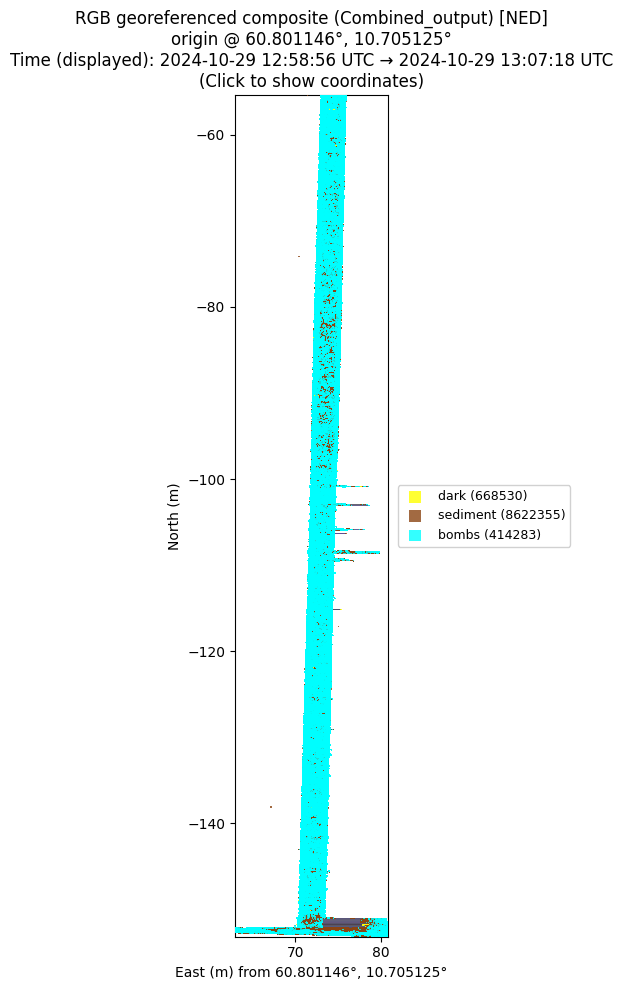

In [29]:
# Plot filtered map (5 classes)
print("📊 Plotting filtered map...")

filtered_rois_028 = {}
for class_name in filtering_results_028["all_classes"]:
    mask = filtering_results_028["filtered_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + track_start_028) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        filtered_rois_028[class_name] = pixels

print(f"\n📊 Pixel counts after filtering:")
for class_name in sorted(filtered_rois_028.keys()):
    print(f"   {class_name}: {len(filtered_rois_028[class_name])} pixels")

cube_028.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=track_start_028,
    track_end=track_end_028,
    figsize=(40, 10),
    roi_collection=filtered_rois_028,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## Merge to Create Final 3-Class Map

In [30]:
# Merge filtered classes into new_sediment
print("\n🔀 MERGING FILTERED CLASSES")
print("=" * 60)

merge_results_028 = cube_028.merge_filtered_to_sediment(
    filtered_map=filtering_results_028["filtered_map"],
    quiet=False,
)

print(f"\n✅ Merge complete!")
print(f"   Final classes: {merge_results_028['class_names']}")


🔀 MERGING FILTERED CLASSES
🔀 MERGING FILTERED CLASSES TO SEDIMENT

📊 Before merge:
   bombs: 414299 pixels
   dark: 668530 pixels
   sediment: 8623307 pixels

📊 Before merge:
   bombs: 414299 pixels
   dark: 668530 pixels
   sediment: 8623307 pixels

🔀 Merged into new_sediment:
   sediment: 8623307 pixels
   ─────────────────────────
   Total: 8623307 pixels

📊 After merge (3 classes for validation):
   classified_bombs: 0 pixels
   classified_dark: 0 pixels
   new_sediment: 0 pixels

✅ Merge complete!
   Final classes: ['classified_bombs', 'classified_dark', 'new_sediment']

🔀 Merged into new_sediment:
   sediment: 8623307 pixels
   ─────────────────────────
   Total: 8623307 pixels

📊 After merge (3 classes for validation):
   classified_bombs: 0 pixels
   classified_dark: 0 pixels
   new_sediment: 0 pixels

✅ Merge complete!
   Final classes: ['classified_bombs', 'classified_dark', 'new_sediment']


📊 Plotting final 3-class map...

📊 Final pixel counts:

📊 Final pixel counts:
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\gref_pipeline\georef.py:1611: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(


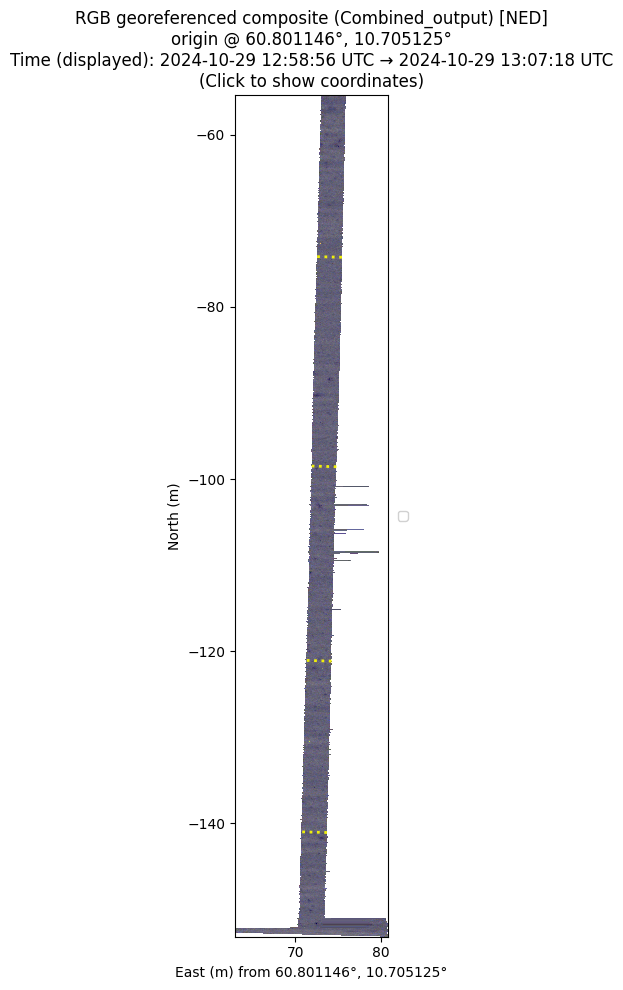

In [31]:
# Plot final 3-class validation map
print("📊 Plotting final 3-class map...")

validation_map_rois_028 = {}
for class_name in merge_results_028["class_names"]:
    mask = merge_results_028["validation_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + track_start_028) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        validation_map_rois_028[class_name] = pixels

print(f"\n📊 Final pixel counts:")
for class_name in sorted(validation_map_rois_028.keys()):
    print(f"   {class_name}: {len(validation_map_rois_028[class_name])} pixels")

cube_028.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=track_start_028,
    track_end=track_end_028,
    figsize=(40, 10),
    roi_collection=validation_map_rois_028,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## Summary

**Part 1 Complete:**
- ✅ Trained SVM on FULL 057_5 transect (all ROIs, no segment filtering)
- ✅ Achieved cross-validation metrics on training data
- ✅ Saved model to file: `svm_model_057_5_full_transect.pkl`

**Part 2 Complete:**
- ✅ Loaded saved model
- ✅ Applied identical preprocessing to 028 transect
- ✅ Classified entire 028 transect using trained model
- ✅ Applied filtering pipeline
- ✅ Created final 3-class map

**Next Steps:**
- Validate results (if you have validation ROIs for 028)
- Try different confidence thresholds
- Apply to additional transects
- Compare classification between transects